In [1]:
import sys
import os
import re
import joblib
import gensim
import numpy as np
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from slovene_pipeline.word2vec_api import Word2VecAPI, maybe_load_emoji2vec
from slovene_pipeline.features import build_tfidf, build_w2v_mean, combine_features
from irony_translation.LLMSarcasmTranslator import LLMSarcasmTranslator
from irony_translation.SarcasmTranslator import T5SarcasmTranslator

from long_text_parser.long_text_classification import classify_text, load_classifier

c:\Users\Lynik\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
MODEL_PATH = os.path.join(project_root, 'slovene_pipeline', 'subtaskA_notebooks', 'finalized_model.sav')

if os.path.exists(MODEL_PATH):
    irony_classifier = joblib.load(MODEL_PATH)
    if isinstance(irony_classifier, dict) and "vectorizer" in irony_classifier:
        vectorizer = irony_classifier["vectorizer"]
        clf = irony_classifier["classifier"]
    else:
        clf = irony_classifier
        vectorizer = None 
else:
    print(f"Model not found at {MODEL_PATH}")

kv = gensim.models.fasttext.load_facebook_model('../w2v-slo/all-token-prelim.ft.sg.bin').wv
w2v = Word2VecAPI(kv)
emoji_model = maybe_load_emoji2vec(
    os.path.join(project_root, 'emoji2vec-master', 'pre-trained', 'emoji2vec.bin'),
    binary=True
)

# Option 1: LLM Translator (Groq/OpenAI base)
API_KEY = "your-api-key-here" 
llm_translator = LLMSarcasmTranslator(api_key=API_KEY)

# Option 2: Local HuggingFace Translator (e.g., mT5 trained on dataset)
local_translator = T5SarcasmTranslator(model_name="csebuetnlp/mT5_multilingual_XLSum")
# Uncomment next line to load local weights if trained locally
local_translator.load_model(os.path.join(project_root, "irony_translation", "from_medium_dataset", "nllb_200_distilled_600M"))

# Choose which one to pass to the pipeline
#translator = llm_translator 
translator = local_translator

Loading weights: 100%|██████████| 284/284 [00:00<00:00, 47194.23it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
Loading weights: 100%|██████████| 509/509 [00:00<00:00, 10810.72it/s]


In [ ]:
# used for splitting longer texts into individual senteneces
def split_sentences(text: str):
    parts = re.split(r'(?<=[.!?]) +', text.strip())
    sentences = [p.strip() for p in parts if p.strip()]
    return sentences

In [4]:
def extract_enhanced_features(tweet_text):
    """
    Extract enhanced NLP features for irony/sarcasm detection.
    Returns exactly 60 features and keeps pragmatic priors in the final slots.
    """
    from ekphrasis.utils.nlp import polarity
    import re

    words = tweet_text.split()
    words_lower = [w.lower() for w in words]

    # SLOVENE SENTIMENT WORDS
    positive_words = ['rad', 'obožujem', 'lepo', 'super', 'odličko', 'hvala', 'rabi', 'rabu',
                      'super', 'great', 'love', 'perfect', 'amazing', 'wonderful', 'fantastic']
    negative_words = ['zaprta', 'zaprto', 'zaprte', 'slabo', 'čudno', 'groza', 'strašno',
                      'problematično', 'dead', 'horrible', 'ugly', 'terrible', 'bad']

    # 1) Positive-negative contradiction
    positive_count = sum(1 for w in words_lower if any(w.startswith(p) or p in w for p in positive_words))
    negative_count = sum(1 for w in words_lower if any(w.startswith(n) or n in w for n in negative_words))
    sarcasm_contrast = 1 if (positive_count > 0 and negative_count > 0) else 0

    # 2) Left-right intensity/contrast
    left_half = words[:len(words)//2]
    right_half = words[len(words)//2:]
    left_word_lens = [len(w) for w in left_half]
    right_word_lens = [len(w) for w in right_half]

    left_intensity = 1 if (sum(left_word_lens) / max(len(left_half), 1)) < 4 else 0
    right_intensity = 1 if (sum(right_word_lens) / max(len(right_half), 1)) < 4 else 0
    polarity_diff = 1 if len(left_half) > 0 and len(right_half) > 0 else 0

    contrast = 0
    try:
        if len(left_half) > 0 and len(right_half) > 0:
            left_text = ' '.join(left_half)
            right_text = ' '.join(right_half)
            left_pol = polarity(left_text)
            right_pol = polarity(right_text)
            if (left_pol and right_pol and len(left_pol) > 1 and len(right_pol) > 1):
                contrast = 1 if abs(left_pol[0] - right_pol[0]) > 0.5 else 0
    except:
        pass

    # 3) Punctuation/linguistic markers
    exclamation_count = tweet_text.count('!')
    question_count = tweet_text.count('?')
    ellipsis_count = tweet_text.count('...')
    ellipsis_signal = 1 if ellipsis_count > 0 else 0
    excessive_punct = 1 if (exclamation_count > 2 or question_count > 2) else 0

    elongated_words = len([w for w in words if re.search(r'(.)\1{2,}', w)])
    elongation_score = min(elongated_words / max(len(words), 1), 1.0)

    slovene_negations = ['ne', 'nema', 'nimam', 'nimajo', 'nič', 'nikoli', 'nobeden', 'brez']
    negation_count = sum(1 for word in words_lower if any(word.startswith(neg) or neg in word for neg in slovene_negations))
    negation_score = min(negation_count / max(len(words), 1), 1.0)

    # Soft sentiment priors for emoji/hashtag slots (feature 56/57)
    emoji_sentiments_map = {
        '🙄': -1, '😒': -1, '😑': -1, '🤦': -1, '🤦\u200d♂️': -1, '🤦\u200d♀️': -1,
        '😬': -1, '😏': -1, '🙃': -1, '🙂': 1, '😊': 1, '😁': 1
    }

    emoji_vals = [val for emo, val in emoji_sentiments_map.items() if emo in tweet_text]
    if emoji_vals:
        neg_ratio = sum(1 for v in emoji_vals if v < 0) / len(emoji_vals)
        mixed = 1.0 if ({-1, 1}.issubset(set(emoji_vals))) else 0.0
        emoji_sentiment_prior = min(1.0, 0.7 * neg_ratio + 0.3 * mixed)
    else:
        emoji_sentiment_prior = 0.0

    hashtag_tokens = [tok[1:] for tok in tweet_text.lower().split() if tok.startswith('#') and len(tok) > 1]
    pos_hash = {'super', 'odlicno', 'vrhunsko', 'hvala', 'top'}
    neg_hash = {'katastrofa', 'groza', 'slabo', 'zamuda', 'problem'}
    pos_hits = sum(1 for h in hashtag_tokens if any(p in h for p in pos_hash))
    neg_hits = sum(1 for h in hashtag_tokens if any(n in h for n in neg_hash))
    if (pos_hits + neg_hits) == 0:
        hashtag_sentiment_prior = 0.0
    else:
        mixed = 1.0 if (pos_hits > 0 and neg_hits > 0) else 0.0
        spread = abs(pos_hits - neg_hits) / max((pos_hits + neg_hits), 1)
        hashtag_sentiment_prior = min(1.0, 0.6 * mixed + 0.4 * (1.0 - spread))

    # 4) Extra pragmatic priors (feature 58/59), soft/capped
    emoji_irony_set = {'🙄', '😒', '😑', '🤦', '🤦\u200d♂️', '🤦\u200d♀️', '😬', '😏', '🙃'}
    inconvenience_patterns = [
        r'\b(še\s+dobro\s+da)\b',
        r'\b(super|odlično|fajn|hvala|vrhunsko)\b.*\b(ko|da)\b.*\b(zamujam|dežuje|zaprta|gužva|gneča|pokvar|crkn|čakanja|čakalnici)'
    ]
    neg_event_hints = ['zamujam', 'dežuje', 'zaprta', 'gužva', 'gneča', 'pokvar', 'crkn', 'čakanja', 'čakalnici']
    pos_ironic_openers = ['super', 'odlično', 'fajn', 'hvala', 'vrhunsko']

    emoji_hits = sum(tweet_text.count(e) for e in emoji_irony_set)
    emoji_irony_prior = min(0.35, 0.12 * min(emoji_hits, 2) + (0.08 if emoji_hits > 0 else 0.0))

    low = tweet_text.lower()
    pat_hits = sum(1 for pat in inconvenience_patterns if re.search(pat, low))
    neg_hits = sum(1 for tok in neg_event_hints if tok in low)
    opener = 1 if any(tok in low for tok in pos_ironic_openers) else 0
    inconvenience_prior = min(0.35, 0.10 * pat_hits + 0.05 * min(neg_hits, 3) + 0.05 * opener)

    # Build exact 60-dim vector: 4 core + 54 aux + 2 pragmatic
    core = [left_intensity, right_intensity, polarity_diff, contrast]

    aux_54 = np.zeros(54, dtype=float)
    # Put heuristic cues in front of aux block
    aux_54[0] = exclamation_count / 5
    aux_54[1] = question_count / 5
    aux_54[2] = ellipsis_count / 3
    aux_54[3] = excessive_punct
    aux_54[4] = elongation_score
    aux_54[5] = negation_score
    aux_54[6] = sarcasm_contrast
    aux_54[7] = ellipsis_signal
    aux_54[8] = positive_count / max(len(words), 1)
    aux_54[9] = negative_count / max(len(words), 1)

    # Keep explicit sentiment priors where training stores them (56/57 overall => 52/53 in aux block)
    aux_54[52] = emoji_sentiment_prior
    aux_54[53] = hashtag_sentiment_prior

    all_feats = core + aux_54.tolist() + [emoji_irony_prior, inconvenience_prior]
    return all_feats

In [ ]:
def is_long_text_ironic(text: str, clf_model=None, w2v_model=None, emoji_model=None, threshold: float = 0.5) -> bool:
    if clf_model is None:
        return False
    try:
        prob = classify_text(text, clf_model, w2v_model=w2v_model, emoji_model=emoji_model)
        return prob >= threshold
    except Exception as e:
        print(f"Error during long text prediction: {e}")
        return False


def is_sentence_ironic(sentence: str, clf_model=None, w2v_model=None, emoji_model=None) -> bool:
    if clf_model is None:
        return False
    try:
        # combining all features (from words2vec, emoji2vec and extract_enhanced_features())
        w2v_feat = build_w2v_mean([sentence], w2v_model, emoji_model)[0]
        enhanced_feat = np.array(extract_enhanced_features(sentence))
        x = np.hstack([w2v_feat, enhanced_feat]).reshape(1, -1)
        preds = clf_model.predict(x)
        return bool(preds[0])
    except Exception as e:
        print(f"Error during sentence prediction: {e}")
        return False

In [6]:
def translate_ironic_sentence(sentence: str, translator_model) -> str:
    try:
        if hasattr(translator_model, 'zero_shot'):
            # Used by LLMSarcasmTranslator
            non_ironic = translator_model.zero_shot(sentence)
        elif hasattr(translator_model, 'generate'):
            # Used by T5SarcasmTranslator
            non_ironic = translator_model.generate(sentence)
        else:
            return sentence
            
        return non_ironic.strip()
    except Exception as e:
        print(f"Translation failed: {e}")
        return sentence

In [7]:
def process_long_text_pipeline(input_text: str, clf_model=None, w2v_model=None, emoji_model=None, translator_model=None):
    is_text_block_ironic = is_long_text_ironic(input_text, clf_model=clf_model, w2v_model=w2v_model, emoji_model=emoji_model)
    
    transformed_details = []
    final_sentences = []
    
    if not is_text_block_ironic:
        return {
            "original_text": input_text,
            "final_text": input_text,
            "is_block_ironic": False,
            "total_sentences": len(split_sentences(input_text)),
            "ironic_count": 0,
            "transformations": []
        }
        
    sentences = split_sentences(input_text)
    
    for i, sentence in enumerate(sentences):
        
        is_ironic = is_sentence_ironic(
            sentence, 
            clf_model=clf_model, 
            w2v_model=w2v_model, 
            emoji_model=emoji_model
        )
        
        if is_ironic and translator_model is not None:
            translated_sentence = translate_ironic_sentence(sentence, translator_model)
            final_sentences.append(translated_sentence)
            
            transformed_details.append({
                "index": i,
                "original": sentence,
                "transformed": translated_sentence
            })
        else:
            final_sentences.append(sentence)
            
    final_string = " ".join(final_sentences)
    
    result = {
        "original_text": input_text,
        "final_text": final_string,
        "is_block_ironic": True,
        "total_sentences": len(sentences),
        "ironic_count": len(transformed_details),
        "transformations": transformed_details
    }
    
    return result

In [8]:
print("clf:", clf)
print("vectorizer:", vectorizer)
print("w2v:", w2v)
print("emoji_model:", emoji_model)
print("translator:", translator)

clf: VotingClassifier(estimators=[('svm',
                              SVC(class_weight='balanced', probability=True,
                                  random_state=11)),
                             ('lr',
                              LogisticRegression(n_jobs=-1, random_state=11))],
                 n_jobs=-1, voting='soft')
vectorizer: None
w2v: Word2VecAPI(keyed_vectors=<gensim.models.fasttext.FastTextKeyedVectors object at 0x00000256AA5DBAD0>)
emoji_model: KeyedVectors<vector_size=300, 1661 keys>
translator: <irony_translation.SarcasmTranslator.T5SarcasmTranslator object at 0x000002569DBD1D90>


In [9]:
sample_texts = [
    "To je bil res odličen dan. Komaj čakam, da ponovimo!",
    "Oh, super, spet dežuje ravno ko grem na morje. Zaprli so tudi mejo. Vrjem, da je to bil res 'odličen' dan.",
    "Oh, kako obožujem dve uri čakanja v koloni. Najboljši način za začetek jutra! 🚗🕰️ #zastoji #ljubljana #sreča",
    "To, da mi telefon crkne pri 2 %, ravno ko potrebujem navigacijo, je brez dvoma moja najljubša funkcija. 📱🔋 #tehnologija #popolno",
    "Uau, še en deževen vikend. Saj sem bil res že pošteno utrujen od preveč sonca letos. 🌧️☔ #vreme #slovenija #komajčakam",
    "Danes sem imel čudovit pohod na Šmarno goro! Razgled je na koncu vedno poplačan. 🏔️☀️ #šmarnagora #hribi #narava"
]

import json

for text in sample_texts:
    CLF = globals().get('clf', None)
    W2V = globals().get('w2v', None)
    EMOJI = globals().get('emoji_model', None)
    TRANS = globals().get('translator', None)
    
    if CLF is None:
        def mock_long_text_ironic(t, *args, **kwargs):
            return "dežuje" in t.lower()
        
        def mock_sentence_ironic(s, *args, **kwargs):
            return "dežuje" in s.lower() or "odličen" in s.lower()
        
        original_is_long = is_long_text_ironic
        original_is_sent = is_sentence_ironic
        is_long_text_ironic = mock_long_text_ironic
        is_sentence_ironic = mock_sentence_ironic
        
    output = process_long_text_pipeline(text, clf_model=CLF, w2v_model=W2V, emoji_model=EMOJI, translator_model=TRANS)
    
    print("-" * 50)
    print(json.dumps(output, indent=2, ensure_ascii=False))
    
    if CLF is None:
        is_long_text_ironic = original_is_long
        is_sentence_ironic = original_is_sent

--------------------------------------------------
{
  "original_text": "To je bil res odličen dan. Komaj čakam, da ponovimo!",
  "final_text": "Žal mi je, ker ni bil dober dan. Komaj čakam, da ponavljam!",
  "is_block_ironic": true,
  "total_sentences": 2,
  "ironic_count": 2,
  "transformations": [
    {
      "index": 0,
      "original": "To je bil res odličen dan.",
      "transformed": "Žal mi je, ker ni bil dober dan."
    },
    {
      "index": 1,
      "original": "Komaj čakam, da ponovimo!",
      "transformed": "Komaj čakam, da ponavljam!"
    }
  ]
}
--------------------------------------------------
{
  "original_text": "Oh, super, spet dežuje ravno ko grem na morje. Zaprli so tudi mejo. Vrjem, da je to bil res 'odličen' dan.",
  "final_text": "Oh, super, spet dežuje ravno ko grem na morje. Zaprli so tudi mejo. Vrjem, da je to bil res 'odličen' dan.",
  "is_block_ironic": false,
  "total_sentences": 3,
  "ironic_count": 0,
  "transformations": []
}
-----------------------

c:\Users\Lynik\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Lynik\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


--------------------------------------------------
{
  "original_text": "To, da mi telefon crkne pri 2 %, ravno ko potrebujem navigacijo, je brez dvoma moja najljubša funkcija. 📱🔋 #tehnologija #popolno",
  "final_text": "To je bila moja najdražja funkcija, ker je telefon pokvarjen ob neprimernem času. 📱🔋 #tehnologija #popolno",
  "is_block_ironic": true,
  "total_sentences": 2,
  "ironic_count": 1,
  "transformations": [
    {
      "index": 0,
      "original": "To, da mi telefon crkne pri 2 %, ravno ko potrebujem navigacijo, je brez dvoma moja najljubša funkcija.",
      "transformed": "To je bila moja najdražja funkcija, ker je telefon pokvarjen ob neprimernem času."
    }
  ]
}
--------------------------------------------------
{
  "original_text": "Uau, še en deževen vikend. Saj sem bil res že pošteno utrujen od preveč sonca letos. 🌧️☔ #vreme #slovenija #komajčakam",
  "final_text": "Žal mi je, ker je deževen vikend. Saj sem bil res že pošteno utrujen od preveč sonca letos. 🌧️☔ #v

In [ ]:
# tu je namesto split sentences pa is ironic je zdruzeno
def classify_sentences(text: str, clf_model, w2v_model, emoji_model, threshold: float = 0.5):
    """Splits text into sentences, classifies each one, returns list of (sentence, is_ironic, probability)."""
    parts = re.split(r'(?<=[.!?]) +', text.strip())
    sentences = [p.strip() for p in parts if p.strip()]
    
    results = []
    for sentence in sentences:
        try:
            w2v_feat = build_w2v_mean([sentence], w2v_model, emoji_model)[0]
            enhanced_feat = np.array(extract_enhanced_features(sentence))
            x = np.hstack([w2v_feat, enhanced_feat]).reshape(1, -1)
            prob = float(clf_model.predict_proba(x)[0, 1])
            is_ironic = prob >= threshold
        except Exception as e:
            print(f"Error classifying sentence: {e}")
            prob = 0.0
            is_ironic = False
        
        results.append((sentence, is_ironic, prob))
    
    return results

In [ ]:
import pandas as pd
# IMPORTANT tu je dejanski experiment
def run_experiment_on_file_long(input_csv_path: str, output_csv_path: str, threshold: float = 0.5):
    df = pd.read_csv(input_csv_path)

    CLF  = globals().get('clf', None)
    W2V  = globals().get('w2v', None)
    EMOJI = globals().get('emoji_model', None)
    TRANS = globals().get('translator', None)

    results = []

    for _, row in df.iterrows():
        text = str(row['vhod'])
        true_ironic_idx = int(row['ironic_sentence_id'])  # -1 means no ironic sentence

        # Split into sentences and classify each
        sentence_results = classify_sentences(text, CLF, W2V, EMOJI, threshold)

        for i, (sentence, predicted_ironic, prob) in enumerate(sentence_results):
            true_ironic = (i == true_ironic_idx)  # ground truth for this sentence

            if true_ironic and predicted_ironic:
                label = 'TP'
            elif not true_ironic and predicted_ironic:
                label = 'FP'
            elif true_ironic and not predicted_ironic:
                label = 'FN'
            else:
                label = 'TN'

            translated = None
            if predicted_ironic and TRANS is not None:
                translated = translate_ironic_sentence(sentence, TRANS)

            results.append({
                'original_text': text,
                'sentence_index': i,
                'sentence': sentence,
                'true_ironic': true_ironic,
                'predicted_ironic': predicted_ironic,
                'probability': round(prob, 4),
                'translated': translated if translated else sentence,
                'TP_FP_TN_FN': label
            })

    out_df = pd.DataFrame(results)
    out_df.to_csv(output_csv_path, index=False, encoding='utf-8-sig')
    print(f"Eksperiment zaključen. Shranjeno v: {output_csv_path}")
    print(f"Skupaj stavkov: {len(out_df)}")
    print(out_df['TP_FP_TN_FN'].value_counts().to_string())

    return out_df


# usage
results_df = run_experiment_on_file_long("test_input.csv", "rezultati_sentence_level.csv")

Eksperiment zaključen. Shranjeno v: rezultati_sentence_level.csv
Skupaj stavkov: 450
TP_FP_TN_FN
TN    257
FP     93
FN     64
TP     36


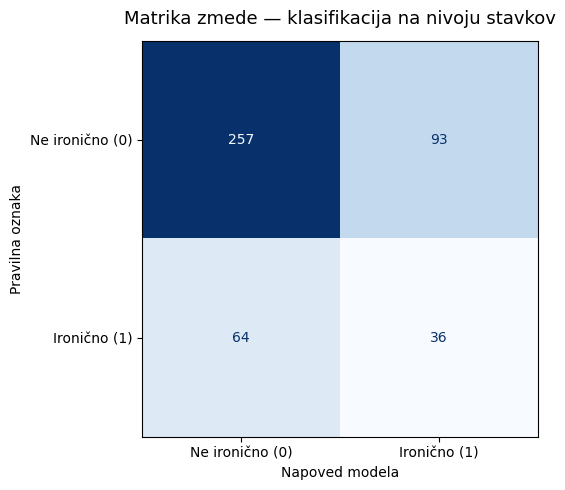

              precision    recall  f1-score   support

 Ne ironično       0.80      0.73      0.77       350
    Ironično       0.28      0.36      0.31       100

    accuracy                           0.65       450
   macro avg       0.54      0.55      0.54       450
weighted avg       0.68      0.65      0.67       450



In [20]:
def plot_confusion_matrix(df):
    import matplotlib.pyplot as plt
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

    y_true = df['true_ironic'].astype(int)
    y_pred = df['predicted_ironic'].map({True: 1, False: 0, 'True': 1, 'False': 0}).astype(int)

    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Ne ironično (0)', 'Ironično (1)']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')

    ax.set_xlabel('Napoved modela')
    ax.set_ylabel('Pravilna oznaka')
    ax.set_title('Matrika zmede — klasifikacija na nivoju stavkov', fontsize=13, pad=12)

    plt.tight_layout()
    plt.show()

    print(classification_report(y_true, y_pred, target_names=['Ne ironično', 'Ironično']))

plot_confusion_matrix(results_df)